Number of record:  1500

Dataset shape:  (1500, 6)

Columns:  Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')

Target Labels: 
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Class Distribution: 
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Text Records: 
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str

Average Text Length:  12.722666666666667


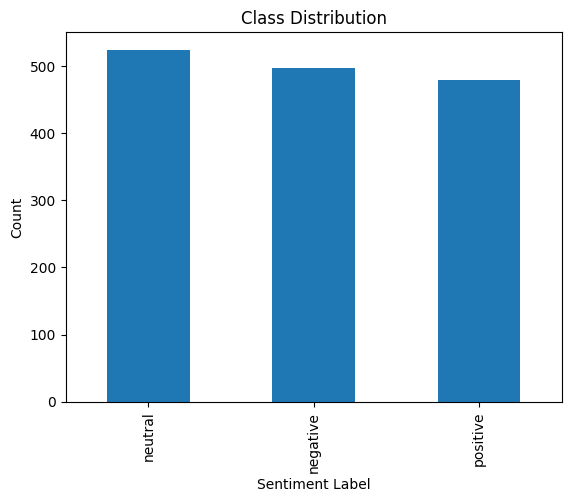


Original Text:  0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str

Cleaned Text:  0    need information payment process ticket number...
1                     need information payment process
2    refund process fast convenient appreciate quic...
3    refund still pending experience frustrating ti...
4                   please tell update account details
Name: cleaned_message, dtype: str
Vecorized Text Shape:  (1500, 633)

Sample Feature Names:  ['10347' '10565' '10632' '10783' '10841' '10973' '11045' '11058' '11213'
 '11482' '11855' '12223' '12238' '12408' '12727' '12970' '13030' '13329'
 '13544' '13589']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\294874\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\294874\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
# Task 1: Dataset Understanding

import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("../dataset/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")

# Number of records
print("Number of record: ", len(df))
print("\nDataset shape: ", df.shape)
print("\nColumns: ", df.columns)

# Target labels/classes
print("\nTarget Labels: ")
print(df['sentiment_label'].unique())

print("\nClass Distribution: ")
print(df['sentiment_label'].value_counts())

# Sample Text Records
print("\nSample Text Records: ")
print(df['customer_message'].head())

# Average Text Length
text_length = df["customer_message"].apply(lambda x: len(str(x).split()))
print("\nAverage Text Length: ", text_length.mean())

# Class distribution
df['sentiment_label'].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.savefig("results/class_distribution.png")
plt.show()


# Task 2: Text Preprocessing
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lower case
    text = text.lower()

    # Removing unnecesssary symbols or special characters
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    cleaned_text = " ".join(tokens)
    return cleaned_text

df['cleaned_message'] = df['customer_message'].apply(preprocess_text)

# Display Sample Results
print("\nOriginal Text: ", df["customer_message"].head())
print("\nCleaned Text: ", df['cleaned_message'].head())


# Task 3: Text Vectorization
# TF-IDF Object
tfidf = TfidfVectorizer(max_features=5000)

# Convert cleaned text into vectors
X = tfidf.fit_transform(df["cleaned_message"])

# Target Variable
y = df["sentiment_label"]

print("Vecorized Text Shape: ", X.shape)

print("\nSample Feature Names: ", tfidf.get_feature_names_out()[:20])

# Explanation - Why text must be converted into vectors before being used by a model

Text must be converted into vectors because machine learning models cannot understand raw text directly. Models work only with numerical data.

TF-IDF converts words into numbers based on:
1) Word frequency in a sentence
2) Importance of the word across the dataset

Words appearing frequently in one document but rarely across others get hugher importance

Accuracy Score:  1.0
Classification Report:                precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:  [[109   0   0]
 [  0 104   0]
 [  0   0  87]]


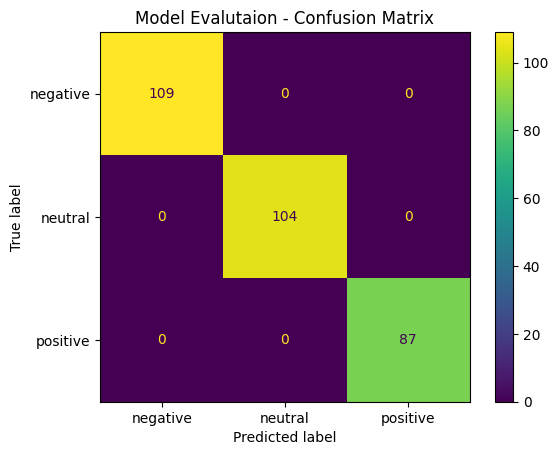

In [42]:
# Task 4: Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Classification Report: ", classification_report(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Model Evalutaion - Confusion Matrix')
plt.savefig("results/model_evaluation.png")
plt.show()

In [43]:
# Task 5: Sequence Model or Conceptual Architecture
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.preprocessing import LabelEncoder

# Sequence Model - LSTM
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(df['cleaned_message'])

sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

max_length = 50

X_seq = pad_sequences(
    sequences,
    maxlen = max_length,
    padding = 'post',
    truncating = 'post'
)

label_encoder = LabelEncoder()

y_seq = label_encoder.fit_transform(df['sentiment_label'])

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_length))

# LSTM Layer
model.add(LSTM(64))

# Output Layer
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\294874\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Task 6: Attention and Transformer Reflection 

## 1. Why RNNs struggle with long-term dependencies

RNNs process text sequentially, one word at a time.  
As sequences become longer, earlier information gradually fades while passing through many hidden states. This leads to the **vanishing gradient problem**, making it difficult for RNNs to remember important information from earlier words in a sentence.

### Example
```text
"The product I ordered last month from your website still has not arrived."
```

A basic RNN may forget the context of *“product ordered last month”* by the time it reaches the final words.

---

## 2. How LSTMs help with memory

LSTMs (Long Short-Term Memory networks) improve RNNs by introducing:
- Forget gate
- Input gate
- Output gate

These gates help the model decide:
- What information to keep
- What information to forget
- What information to pass forward

This allows LSTMs to remember long-term dependencies more effectively than traditional RNNs.

---

## 3. What attention solves in sequence-to-sequence tasks

Attention mechanisms allow the model to focus on the most relevant words in the input sequence while making predictions.

Instead of relying only on the final hidden state, attention gives importance scores to different words.

### Example
```text
"The delivery was delayed but customer support was helpful."
```

While predicting sentiment for *helpful*, the attention mechanism focuses more on *customer support* rather than unrelated words.

### Benefits
- Better handling of long sentences
- Improved context understanding
- Better translation and text generation performance

---

## 4. Why transformers are important in modern NLP and Generative AI

Transformers use **self-attention mechanisms** instead of sequential processing.

### Advantages
- Process words in parallel
- Capture long-range dependencies efficiently
- Faster training compared to RNNs/LSTMs
- Better contextual understanding

Transformers are the foundation of modern NLP models such as:
- BERT
- GPT
- T5

### Applications
- Chatbots
- Text generation
- Translation
- Summarization
- Sentiment analysis

Generative AI systems like ChatGPT are built using transformer architectures because they can understand and generate human-like language effectively.
